Cell 1 — Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from src.utils.data_loader import load_dataset
from src.pipeline.base import ArabicTextPipeline
from src.pipeline.steps import (
    DiacriticsRemover,
    Normalizer,
    ElongationNormalizer,
    PunctuationRemover,
    StopwordRemover,
)
from src.utils.experiment import run_experiment

Cell 2 — Define ablation configs

In [2]:
twitter_df = load_dataset("twitter")

ALL_STEPS = [
    DiacriticsRemover(),
    Normalizer(),
    ElongationNormalizer(),
    PunctuationRemover(),
    StopwordRemover(),
]

# each config drops exactly one step
ABLATION_CONFIGS = {
    "full_pipeline":        ALL_STEPS,
    "no_diacritics":        [Normalizer(), ElongationNormalizer(), PunctuationRemover(), StopwordRemover()],
    "no_normalization":     [DiacriticsRemover(), ElongationNormalizer(), PunctuationRemover(), StopwordRemover()],
    "no_elongation":        [DiacriticsRemover(), Normalizer(), PunctuationRemover(), StopwordRemover()],
    "no_punctuation":       [DiacriticsRemover(), Normalizer(), ElongationNormalizer(), StopwordRemover()],
    "no_stopwords":         [DiacriticsRemover(), Normalizer(), ElongationNormalizer(), PunctuationRemover()],
}

print(f"Running {len(ABLATION_CONFIGS)} ablation configs...")

Running 6 ablation configs...


Cell 3 — Run ablation

In [3]:
from sklearn.svm import LinearSVC
from src.utils.experiment import MODELS

# override MODELS to only use LinearSVC for speed
import src.utils.experiment as exp_module
exp_module.MODELS = {"LinearSVC": LinearSVC(max_iter=2000)}

ablation_results = []

for config_name, steps in ABLATION_CONFIGS.items():
    pipeline = ArabicTextPipeline(steps)
    results = run_experiment(twitter_df, pipeline, config_name, vectorizer_mode="word")
    ablation_results.append({
        "config": config_name,
        "f1_macro": results[0].f1_macro,
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("f1_macro", ascending=False)
print(ablation_df.to_string(index=False))
ablation_df.to_csv("../results/ablation_results.csv", index=False)


Dataset: full_pipeline | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7715 | F1 weighted: 0.7715

Dataset: no_diacritics | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7715 | F1 weighted: 0.7715

Dataset: no_normalization | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7695 | F1 weighted: 0.7695

Dataset: no_elongation | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7711 | F1 weighted: 0.7711

Dataset: no_punctuation | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7693 | F1 weighted: 0.7693

Dataset: no_stopwords | Vectorizer: word
Preprocessing...
Vectorizing...
Vocabulary size: 15000
Training LinearSVC...
  F1 macro: 0.7655 | F1 weighted: 0.7655
          config  f1_macro
   f

Cell 4 — Visualize

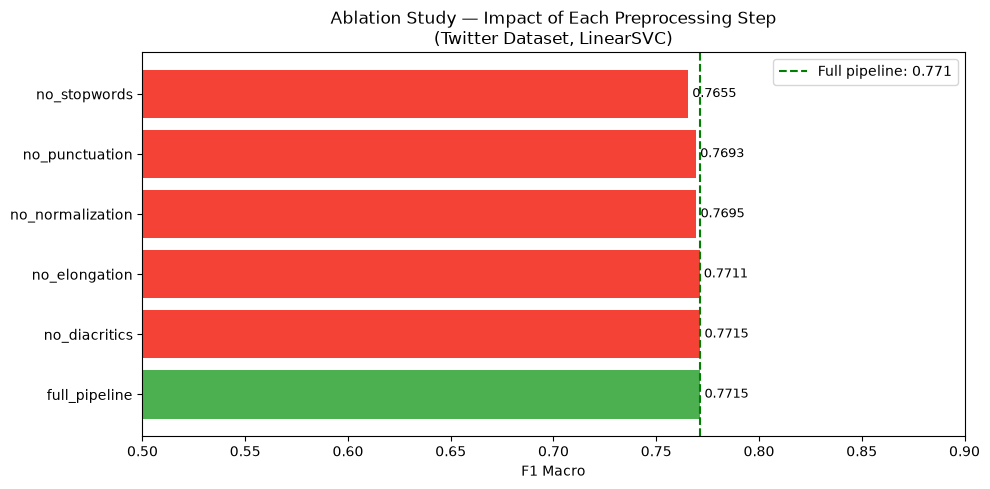

In [4]:
baseline = ablation_df[ablation_df["config"] == "full_pipeline"]["f1_macro"].values[0]

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#4CAF50" if c == "full_pipeline" else "#F44336" 
          for c in ablation_df["config"]]

bars = ax.barh(ablation_df["config"], ablation_df["f1_macro"], color=colors)

ax.axvline(x=baseline, color="green", linestyle="--", linewidth=1.5, label=f"Full pipeline: {baseline:.3f}")
ax.set_xlabel("F1 Macro")
ax.set_title("Ablation Study — Impact of Each Preprocessing Step\n(Twitter Dataset, LinearSVC)", fontsize=12)
ax.set_xlim(0.5, 0.9)

for bar, val in zip(bars, ablation_df["f1_macro"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

ax.legend()
plt.tight_layout()
plt.savefig("../results/ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()